#Step 1: Video Capture and Frame Extraction

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

import cv2
import os

def capture_video(person_name):
    cap = cv2.VideoCapture(0)  # Open default camera
    if not os.path.exists(f"dataset/{person_name}"):
        os.makedirs(f"dataset/{person_name}")

    frame_count = 0
    while frame_count < 100:  # Set a limit for frames per person
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow("Capturing Video", frame)

        # Save frames at intervals (e.g., every 5th frame)
        if frame_count % 5 == 0:
            cv2.imwrite(f"dataset/{person_name}/frame_{frame_count}.jpg", frame)

        frame_count += 1

        if cv2.waitKey(1) & 0xFF == ord('q'):  # Press 'q' to quit early
            break

    cap.release()
    cv2.destroyAllWindows()


#Step 1: Video Capture and Frame Extraction with gradio


import gradio as gr
import cv2
import os

# Function to capture video frames and save them
def capture_video(person_name):
    cap = cv2.VideoCapture(0)  # Open the default camera
    save_dir = f"dataset/{person_name}"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    frame_count = 0
    saved_frames = 0
    while frame_count < 500:  # Set a limit for frames per person
        ret, frame = cap.read()
        if not ret:
            break

        # Display the camera feed
        cv2.imshow("Capturing Frames - Press 'q' to Quit", frame)

        # Save every 5th frame
        if frame_count % 5 == 0:
            frame_path = f"{save_dir}/frame_{saved_frames}.jpg"
            cv2.imwrite(frame_path, frame)
            saved_frames += 1

        frame_count += 1
        if cv2.waitKey(1) & 0xFF == ord('q'):  # Press 'q' to quit early
            break

    cap.release()
    cv2.destroyAllWindows()
    return f"Captured and saved {saved_frames} frames for {person_name}."

# Gradio Interface
with gr.Blocks() as app:
    gr.Markdown("# Video Capture for Face Recognition Dataset")
    person_name = gr.Textbox(label="Person's Name", placeholder="Enter name for dataset folder")
    capture_button = gr.Button("Start Capture")
    output = gr.Textbox(label="Capture Output")

    capture_button.click(fn=capture_video, inputs=person_name, outputs=output)

app.launch()


In [10]:
!pip install gradio

#creating data frames without grey scale


In [3]:
import gradio as gr
print("successful")

successful


In [7]:
import cv2
import os
import gradio as gr

def capture_video_and_detect_faces(person_name):
    cap = cv2.VideoCapture(0)
    
    #C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    frame_count = 0
    saved_frames = 0
    while frame_count < 100:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        # Display the camera feed with detected faces and rectangles
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Draw rectangle
            # Save the frame with rectangle (optional)
            # frame_path_rect = f"{save_dir}/frame_{saved_frames}_rect.jpg"
            # cv2.imwrite(frame_path_rect, frame)

            # Extract and save the face region
            face = frame[y:y + h, x:x + w]
            face_path = f"{save_dir}/face_{saved_frames}.jpg"
            cv2.imwrite(face_path, face)
            saved_frames += 1

        cv2.imshow("Capturing Frames - Press 'q' to Quit", frame)

        frame_count += 1
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    return f"Captured and saved {saved_frames} frames with faces for {person_name}."
with gr.Blocks() as app:
  gr.Markdown("# Video Capture for Face Recognition Dataset with Face Detection")
  person_name = gr.Textbox(label="Person's Name", placeholder="Enter name for dataset folder")
  capture_button = gr.Button("Start Capture")
  output = gr.Textbox(label="Capture Output")

  capture_button.click(fn=capture_video_and_detect_faces, inputs=person_name, outputs=output)

app.launch(debug=True)

Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "C:\Users\hemas\anaconda3\lib\site-packages\gradio\queueing.py", line 536, in process_events
    response = await route_utils.call_process_api(
  File "C:\Users\hemas\anaconda3\lib\site-packages\gradio\route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
  File "C:\Users\hemas\anaconda3\lib\site-packages\gradio\blocks.py", line 1935, in process_api
    result = await self.call_function(
  File "C:\Users\hemas\anaconda3\lib\site-packages\gradio\blocks.py", line 1520, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
  File "C:\Users\hemas\anaconda3\lib\site-packages\anyio\to_thread.py", line 28, in run_sync
    return await get_asynclib().run_sync_in_worker_thread(func, *args, cancellable=cancellable,
  File "C:\Users\hemas\anaconda3\lib\site-packages\anyio\_backends\_asyncio.py", line 818, in run_sync_in_worker_thread
    return await future
  File "C:\Users\hemas\anacon

Keyboard interruption in main thread... closing server.


#creating data frames with grey scale

In [6]:
import cv2
import gradio as gr
import os
from PIL import Image
def capture_video_and_detect_faces(person_name):
    cap = cv2.VideoCapture(0)
    save_dir = rf"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\{person_name}"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    frame_count = 0
    saved_frames = 0
    while frame_count < 100:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            face_gray = gray[y:y+h, x:x+w]  # Extract grayscale face region
            face_img = Image.fromarray(face_gray)  # Convert grayscale face to PIL Image
            face_path = f"{save_dir}/face_{saved_frames}.jpg"
            face_img.save(face_path)
            saved_frames += 1

        cv2.imshow("Capturing Frames - Press 'q' to Quit", frame)

        frame_count += 1
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    return f"Captured and saved {saved_frames} frames with faces for {person_name}."
with gr.Blocks() as app:
  gr.Markdown("# Video Capture for Face Recognition Dataset with Face Detection")
  person_name = gr.Textbox(label="Person's Name", placeholder="Enter name for dataset folder")
  capture_button = gr.Button("Start Capture")
  output = gr.Textbox(label="Capture Output")

  capture_button.click(fn=capture_video_and_detect_faces, inputs=person_name, outputs=output)

app.launch()

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


 #Face Detection and Dataset Creation

In [1]:
import os

dataset = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset"

# Check if dataset directory exists
if not os.path.exists(dataset):
    print("Dataset path is incorrect!")

# Check classes
classes = os.listdir(dataset)
print("Classes:", classes)

# Check if images exist in each class
for cls in classes:
    class_path = os.path.join(dataset, cls)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        print(f"Class {cls} has {len(images)} images")


Classes: ['bashi', 'deepak', 'Hema', 'Hemasree', 'others', 'siva', 'thanuja']
Class bashi has 93 images
Class deepak has 100 images
Class Hema has 70 images
Class Hemasree has 41 images
Class others has 185 images
Class siva has 108 images
Class thanuja has 120 images


#Step 3: Data Preprocessing and CNN Model Training

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
def load_data(img_height, img_width):
    dataset = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset"

    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.1,   # Rescaling factor for pixel values
        shear_range=0.2,  # Shear intensity (optional)
        zoom_range=0.2,  # Random zoom range (optional)
        horizontal_flip=True  # Randomly flip images horizontally (optional)
    )
    train_data = datagen.flow_from_directory(
        dataset,
        target_size=(img_height, img_width),
        batch_size=32,
        class_mode="categorical",
        subset="training"  # This was missing
    )
    
    '''val_data = datagen.flow_from_directory(
        dataset,
        target_size=(img_height, img_width),
        batch_size=32,
        class_mode="categorical",
        subset="validation"
    )'''

    val_data = datagen.flow_from_directory(
            dataset,
            target_size=(img_height, img_width),
            batch_size=32,
            class_mode="categorical",
            subset="validation"
        )
    
    return train_data, val_data
#print(f"Found {train_data.samples} training images.")
#print(f"Found {val_data.samples} validation images.")
print("yes")

yes


def create_model(input_shape, num_classes):
    # Create the Base Model
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model (optional)
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add Custom Top Layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust the number of classes as needed
    
    # Create the Final Model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compile the Model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.summary()

    return model

# Load data and train model
img_height, img_width = 299, 299
train_data, val_data = load_data(img_height, img_width)
num_classes = len(train_data.class_indices)
model_densenet = create_model((img_height, img_width, 3), num_classes)

model_densenet.fit(train_data, validation_data=val_data, epochs=35)


from sklearn.metrics import classification_report
def evaluate_model(model, test_data):
    test_loss, test_acc = model.evaluate(test_data)
    print('Test accuracy:', test_acc)

    # Get predictions on the test data
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred_classes)
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred_classes))
   
evaluate_model(model_densenet, val_data)

def create_model(input_shape, num_classes):
    # Create the Base Model
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model (optional)
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add Custom Top Layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust the number of classes as needed
    
    # Create the Final Model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compile the Model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.summary()

    return model

# Load data and train model
img_height, img_width = 100, 100
train_data, val_data = load_data(img_height, img_width)
num_classes = len(train_data.class_indices)
model = create_model((img_height, img_width, 3), num_classes)

model.fit(train_data, validation_data=val_data, epochs=35)


from sklearn.metrics import classification_report
def evaluate_model(model, test_data):
    test_loss, test_acc = model.evaluate(test_data)
    print('Test accuracy:', test_acc)

    # Get predictions on the test data
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred_classes)
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred_classes))
   
evaluate_model(model, val_data)

def create_model(input_shape, num_classes):
    # Create the Base Model
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model (optional)
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add Custom Top Layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust the number of classes as needed
    
    # Create the Final Model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compile the Model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.summary()

    return model

# Load data and train model
img_height, img_width = 64, 64
train_data, val_data = load_data(img_height, img_width)
num_classes = len(train_data.class_indices)
model_effect = create_model((img_height, img_width, 3), num_classes)

model_effect.fit(train_data, validation_data=val_data, epochs=35)


from sklearn.metrics import classification_report
def evaluate_model(model, test_data):
    test_loss, test_acc = model.evaluate(test_data)
    print('Test accuracy:', test_acc)

    # Get predictions on the test data
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred_classes)
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred_classes))
   
evaluate_model(model_effect, val_data)

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
def create_cnn_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional Block 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Convolutional Block 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Convolutional Block 3
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model
img_height, img_width = 64, 64
train_data, val_data = load_data(img_height, img_width)
num_classes = len(train_data.class_indices)
model_cnn = create_cnn_model((img_height, img_width, 3), num_classes)

model_cnn.fit(train_data, validation_data=val_data, epochs=20)

from sklearn.metrics import classification_report
def evaluate_model(model, test_data):
    test_loss, test_acc = model.evaluate(test_data)
    print('Test accuracy:', test_acc)

    # Get predictions on the test data
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred_classes)
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred_classes))
   
evaluate_model(model_cnn, val_data)

In [5]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout


def create_model(input_shape, num_classes):
    # Create the Base Model
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model (optional)
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add Custom Top Layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust the number of classes as needed
    
    # Create the Final Model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compile the Model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.summary()

    return model

# Load data and train model
img_height, img_width = 100, 100
train_data, val_data = load_data(img_height, img_width)
num_classes = len(train_data.class_indices)
model = create_model((img_height, img_width, 3), num_classes)

model.fit(train_data, validation_data=val_data, epochs=20)


Found 647 images belonging to 7 classes.
Found 70 images belonging to 7 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 49, 49, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 49, 49, 32)        │              96 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 49, 49, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 47, 47, 32)        │           9,216 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 47, 47, 32)        │              96 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 47, 47, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 47, 47, 64)        │          18,432 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 47, 47, 64)        │             192 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 47, 47, 64)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 23, 23, 64)        │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 23, 23, 80)        │           5,120 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 23, 23, 80)        │             240 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 23, 23, 80)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 21, 21, 192)       │         138,240 │ activation_3[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 21,817,127 (83.23 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

C:\Users\hemas\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 680ms/step - accuracy: 0.3818 - loss: 1.6442 - val_accuracy: 0.7143 - val_loss: 0.8440
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step - accuracy: 0.8154 - loss: 0.7055 - val_accuracy: 0.9143 - val_loss: 0.5680
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step - accuracy: 0.8716 - loss: 0.4847 - val_accuracy: 0.9143 - val_loss: 0.4242
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - accuracy: 0.9263 - loss: 0.3402 - val_accuracy: 0.8571 - val_loss: 0.4165
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.9320 - loss: 0.3036 - val_accuracy: 0.9143 - val_loss: 0.3558
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.9380 - loss: 0.2676 - val_accuracy: 0.9143 - val_loss: 0.2636
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.9545 - loss: 0.2039 - val_accuracy: 0.9571 - val_loss: 0.1849
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 269ms/step - accuracy: 0.9647 - loss: 0.1781 - val_accuracy: 0

In [6]:
print(len(model.layers))

313


In [6]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def evaluate_model(model, test_data):
    test_loss, test_acc = model.evaluate(test_data)
    print('Test accuracy:', test_acc)

    # Get predictions on the test data
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred_classes)
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred_classes))
   
evaluate_model(model, val_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9551 - loss: 0.1428
Test accuracy: 0.9571428298950195
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1000ms/step
Confusion Matrix:
[[2 0 1 1 1 0 2]
 [0 0 0 0 2 0 2]
 [2 0 0 0 1 3 3]
 [0 1 1 1 5 2 0]
 [2 0 4 2 4 4 2]
 [0 1 2 2 4 0 1]
 [1 2 1 4 1 1 2]]
Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.29      0.29         7
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         9
           3       0.10      0.10      0.10        10
           4       0.22      0.22      0.22        18
           5       0.00      0.00      0.00        10
           6       0.17      0.17      0.17        12

    accuracy                           0.13        70
   macro avg       0.11      0.11      0.11        70
weighted avg       0.13      0.13      0.13        70



from tensorflow.keras.applications.vgg16 import VGG16
def create_model(input_shape, num_classes):
    # Create the Base Model
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the base model (optional)
    for layer in base_model.layers:
        layer.trainable = False
    
    # Add Custom Top Layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust the number of classes as needed
    
    # Create the Final Model
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compile the Model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.summary()

    return model

# Load data and train model
img_height, img_width = 64, 64
train_data, val_data = load_data(img_height, img_width)
num_classes = len(train_data.class_indices)
model2 = create_model((img_height, img_width, 3), num_classes)

model2.fit(train_data, validation_data=val_data, epochs=20)


from sklearn.metrics import classification_report
def evaluate_model(model, test_data):
    test_loss, test_acc = model.evaluate(test_data)
    print('Test accuracy:', test_acc)

    # Get predictions on the test data
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(y_true, y_pred_classes)
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred_classes))
   
evaluate_model(model2, val_data)

In [7]:
from tensorflow.keras.preprocessing import image

def predict_single_image(model, img_path):
  """
  Predicts the class of a single image.

  Args:
      model: The trained model.
      img_path: Path to the image file.

  Returns:
      A list containing the predicted class label and its probability.
  """

  # Load the image and preprocess it
  img = image.load_img(img_path, target_size=(img_height, img_width))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)  # Add a batch dimension
  x = x / 255.0  # Rescale pixel values

  # Make prediction
  predictions = model.predict(x)

  # Get the predicted class label and its probability
  predicted_class = np.argmax(predictions[0])
  predicted_proba = predictions[0][predicted_class]

  # Get class labels (assuming you have a mapping)
  class_labels = train_data.class_indices  # Replace with your actual class label retrieval method
  class_name = list(class_labels.keys())[list(class_labels.values()).index(predicted_class)]

  return [class_name, predicted_proba]

# Example Usage
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\Hemasree\face_8.jpg"  # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: Hemasree
Probability: 0.52


In [8]:
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\bashi\face_1.jpg" # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted Class: bashi
Probability: 0.92


In [9]:
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\siva\face_26.jpg"  # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Predicted Class: siva
Probability: 0.97


In [10]:
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\thanuja\face_1.jpg"  # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Class: thanuja
Probability: 1.00


In [11]:
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\siva\face_1.jpg"  # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: siva
Probability: 0.98


In [12]:
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\bashi\face_26.jpg"  # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Class: bashi
Probability: 0.98


In [10]:
img_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\siva\face_1.jpg"  # Replace with your image path
class_name, probability = predict_single_image(model, img_path)

print(f"Predicted Class: {class_name}")
print(f"Probability: {probability:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Class: siva
Probability: 0.97


In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# ... (rest of your code, including model training)

def predict_single_image_from_webcam():
    cap = cv2.VideoCapture(0)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not capture image")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        # Capture and predict only if a face is detected
        if len(faces) > 0:
            (x, y, w, h) = faces[0]
            face_img = frame[y:y+h, x:x+w]

            # Preprocess the face image
           
            img = cv2.resize(face_img, (100, 100))
            x = np.expand_dims(img, axis=0) / 255.0

            # Make prediction
            predictions = model.predict(x)
            predicted_class_index = np.argmax(predictions[0])
            predicted_proba = predictions[0][predicted_class_index]

            # Get class label (assuming you have a mapping)
            class_labels = train_data.class_indices  # Replace with your actual class label retrieval method
            class_name = list(class_labels.keys())[predicted_class_index]

            print(f"Predicted Class: {class_name}")
            print(f"Probability: {predicted_proba:.2f}")

        # Break the loop after capturing and predicting on one face
        break

    cap.release()
    cv2.destroyAllWindows()

# Example usage
predict_single_image_from_webcam()

(100, 100, 3)


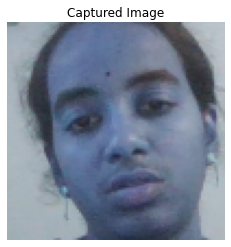

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicted Class: Hemasree
Probability: 0.33


In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array

# ... (rest of your code, including model training)

def predict_single_image_from_webcam():
  cap = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

  while True:
    ret, frame = cap.read()
    if not ret:
      print("Error: Could not capture image")
      break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    # Capture and predict only if a face is detected
    if len(faces) > 0:
      (x, y, w, h) = faces[0]
      face_img = frame[y:y+h, x:x+w]

      # Preprocess the face image
      #img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RG)
      img = cv2.resize(face_img, (100, 100))
      print(img.shape)
      x = np.expand_dims(img, axis=0) / 255.0
      plt.imshow(img)
      plt.title('Captured Image')
      plt.axis('off')
      plt.show()
      # Make prediction
      predictions = model.predict(x)
      predicted_class_index = np.argmax(predictions[0])
      predicted_proba = predictions[0][predicted_class_index]
      labels = {v: k for k, v in train_data.class_indices.items()}
      # Get class label (assuming you have a mapping)
      #class_labels = train_data.class_indices  # Replace with your actual class label retrieval method
      #class_name = list(labels.keys())[predicted_class_index]
      #class_labels = train_data.class_indices  # Replace with your actual class label retrieval method
      #class_name = list(class_labels.keys())[list(class_labels.values()).index(predictions[0])]
      class_labels = train_data.class_indices  # Replace with your actual class label retrieval method
      class_name = list(class_labels.keys())[list(class_labels.values()).index(predicted_class_index)]
      print(f"Predicted Class: {class_name}")
      print(f"Probability: {predicted_proba:.2f}")

      # Display captured face with prediction
      

      # Break the loop after capturing and predicting on one face
      if cv2.waitKey(1) & 0xFF == ord('q'):
        break
      break
  cap.release()
  cv2.destroyAllWindows()

# Example usage
predict_single_image_from_webcam()

In [28]:
class_labels = train_data.class_indices  # Replace with your actual 
class_labels.keys()

dict_keys(['Hema', 'Hemasree', 'bashi', 'deepak', 'others', 'siva', 'thanuja'])

In [30]:
np.save("class_indices.npy", train_data.class_indices)
model.save("face_recognition.h5")

In [19]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

#bounding boxes code

In [1]:
# File: face_prediction_with_bounding_boxes.py

import cv2
import numpy as np

def detect_and_predict_faces(image_path: str, model, labels: dict, output_path: str = "output_with_predictions.jpg"):
    """
    Detects faces in an image, draws bounding boxes, and adds predictions from a pre-trained model.

    :param image_path: Path to the input image.
    :param model: A pre-trained model for face classification (e.g., a neural network).
    :param labels: A dictionary mapping class indices to names (e.g., {0: 'Person A', 1: 'Person B'}).
    :param output_path: Path to save the output image with bounding boxes and predictions.
    """
    # Load the Haar cascade classifier for face detection
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    if face_cascade.empty():
        raise IOError("Failed to load Haar cascade. Ensure the XML file is available.")

    # Read the input image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Convert to grayscale for face detection
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.3, minNeighbors=5, minSize=(30, 30))
    
    # Loop through detected faces
    for (x, y, w, h) in faces:
        # Extract face ROI
        face_roi = gray_image[y:y+h, x:x+w]
        
        # Preprocess face ROI for the model (resize and normalize)
        face_resized = cv2.resize(face_roi, (100, 100))
        print(face_resized.shape)  # Should be (100, 100, 3)
        face_resized = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)# Example size, adjust based on your model
        print(face_resized.shape)  # Should be (100, 100, 3)

        face_input = np.expand_dims(face_resized, axis=0) / 255.0
        #face_normalized = face_resized / 255.0  # Normalize pixel values to [0, 1]
        #face_input = np.expand_dims(face_normalized)  # Add batch and channel dimensions
        
        # Predict using the pre-trained model
        predictions = model.predict(face_input)
        class_index = np.argmax(predictions)  # Get the class index with the highest probability
        label = list(labels.keys())[class_index]
        print(label)
        #label = labels.get(class_index, "Unknown")  # Get the corresponding label

        # Draw bounding box and prediction label
        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)  # Blue rectangle
        cv2.putText(image, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)  # Green text above box

    # Save the output image
    cv2.imwrite(output_path, image)
    print(f"Output image with predictions saved at {output_path}")


# Example usage

import tensorflow as tf  # Example library for loading your model

# Load your trained model (adjust as needed)
model_path = "face_recognition.h5"  # Replace with your model path
model = tf.keras.models.load_model(model_path)

# Define labels (class index to name mapping)
labels = np.load('class_indices.npy', allow_pickle=True).item()

# Input and output image paths
output_image_path = "output_with_predictions.jpg"

input_image_path = r"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\siva\face_0.jpg"  # Replace with your image path
# Run detection and prediction
detect_and_predict_faces(input_image_path, model, labels, output_image_path)


(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
siva
Output image with predictions saved at output_with_predictions.jpg


In [9]:
# test code #
path=r'C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset'
for fname in ['siva', 'thanuja', 'bashi', 'Hema']:
    input_image_path = fr"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\{fname}\face_2.jpg"  # Replace with your image path
    # Run detection and prediction
    print('actual :', fname)
    print('predicted :')
    detect_and_predict_faces(input_image_path, model, labels, output_image_path)


actual : siva
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
siva
Output image with predictions saved at output_with_predictions.jpg
actual : thanuja
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
thanuja
Output image with predictions saved at output_with_predictions.jpg
actual : bashi
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
bashi
Output image with predictions saved at output_with_predictions.jpg
actual : Hema
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Hema
Output image with predictions saved at output_with_predictions.jpg


In [11]:
# test code 2 #

# test code #



path=r'C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset'
for fname in ['siva', 'thanuja', 'bashi', 'Hema']:
    input_image_path = fr"C:\Users\hemas\Desktop\{fname}_images\two.jpg"
    #input_image_path = fr"C:\Users\hemas\Desktop\major proj\weapon_detection\weapon_detection\face_recognition_dataset\face_recognition_dataset\{fname}\face_2.jpg"  # Replace with your image path
    # Run detection and prediction
    print('actual :', fname)
    print('predicted :')
    detect_and_predict_faces(input_image_path, model, labels, output_image_path)

    

actual : siva
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
deepak
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
others
Output image with predictions saved at output_with_predictions.jpg
actual : thanuja
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
thanuja
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
others
Output image with predictions saved at output_with_predictions.jpg
actual : bashi
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
bashi
Output image with predictions saved at output_with_predictions.jpg
actual : Hema
predicted :
(100, 100)
(100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
others
Output image with predictions saved at output_with_predictions.jpg


In [52]:
!pip install torch

In [56]:
!pip install pytorch==1.13.1

ERROR: Could not find a version that satisfies the requirement pytorch==1.13.1 (from versions: 0.1.2, 1.0.2)
ERROR: No matching distribution found for pytorch==1.13.1
